In [1]:
import numpy as np


In [4]:
data =np.array([[1,2,3],[4,5,6],[7,8,9],[5,6,3]])

In [5]:
data.shape

(4, 3)

In [6]:
rgen = np.random.RandomState(10)
w_ = rgen.normal(loc=0.0, scale=0.01, size=data.shape[1])

In [7]:
w_

array([ 0.01331587,  0.00715279, -0.015454  ])

In [11]:
net_input=np.dot(data,w_)
net_input.shape
act =1. / (1. + np.exp(-np.clip(net_input, -250, 250)))
act.shape


(4,)

In [12]:
act

array([0.495315  , 0.49907585, 0.50283681, 0.51577827])

In [14]:
np.dot(data.T,act)

array([ 8.5903674 , 10.60337333, 10.55326616])

In [16]:
np.dot(act,data)

array([ 8.5903674 , 10.60337333, 10.55326616])

In [17]:
x =np.dot(act,np.log(act))


In [18]:
x


np.float64(-1.3820261757761398)

In [1]:
import numpy as np

# Create a 1D array
arr = np.arange(1, 13)
print(f"Original array: {arr}")
print(f"Original shape: {arr.shape}\n")

# Reshape to 2D
arr_2d = arr.reshape(3, 4)
print(f"2D array:\n{arr_2d}\n")

# Reshape to 3D
arr_3d = arr.reshape(2, 3, 2)
print(f"3D array:\n{arr_3d}\n")

# Use -1 for automatic dimension
arr_auto = arr.reshape(4, -1)
print(f"Auto-calculated columns (shape {arr_auto.shape}):\n{arr_auto}\n")

# Flatten the array
arr_flat = arr_2d.reshape(-1)
print(f"Flattened array:\n{arr_flat}\n")

Original array: [ 1  2  3  4  5  6  7  8  9 10 11 12]
Original shape: (12,)

2D array:
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

3D array:
[[[ 1  2]
  [ 3  4]
  [ 5  6]]

 [[ 7  8]
  [ 9 10]
  [11 12]]]

Auto-calculated columns (shape (4, 3)):
[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]

Flattened array:
[ 1  2  3  4  5  6  7  8  9 10 11 12]



In [12]:
np.random.seed(1)
X_xor = np.random.randn(200, 2)
y_xor = np.logical_xor(X_xor[:, 0] > 0,X_xor[:, 1] > 0)
y_xor = np.where(y_xor, 1, 0)
y_xor.shape

(200,)

<function matplotlib.pyplot.show(close=None, block=None)>

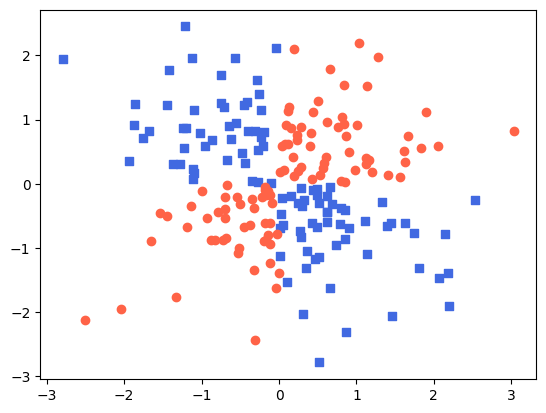

In [13]:
import matplotlib.pyplot as plt
plt.scatter(X_xor[y_xor == 1, 0],X_xor[y_xor == 1, 1],c='royalblue', marker='s',
label='Class 1')
plt.scatter(X_xor[y_xor == 0, 0],X_xor[y_xor == 0, 1],c='tomato', marker='o',label='Class 0')
plt.show

In [2]:
import numpy as np
import time
x =[1.,2.,3.]
w =[0.1,0.2,0.3]


In [3]:

start_time = time.perf_counter()
z =0
for i in range(len(x)):
    z+=x[i]*w[i]
end_time = time.perf_counter()
print(z,end_time-start_time)

1.4 5.320799982655444e-05


In [4]:

start_time = time.perf_counter()
z =sum([i*o for i,o in zip(x,w)])
end_time = time.perf_counter()
print(z,end_time-start_time)

1.4 4.3125000047439244e-05


In [6]:

start_time = time.perf_counter()
a =np.array(x)
b=np.array(w)
z = np.dot(a.T,b)
end_time = time.perf_counter()
print(z,end_time-start_time)

1.4 0.00010041600035037845


In [9]:

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def train_logistic_regression(X, y, lr=0.01, epochs=1):

    m, n = X.shape
    
    # initialize parameters
    w = np.zeros(n)
    b = 0

    for i in range(epochs):

        # forward pass
        z = np.dot(X, w) + b
        print(z)
        y_hat = sigmoid(z)

        # gradients
        dw = (1/m) * np.dot(X.T, (y_hat - y))
        print(X.T)
        print((y_hat - y))
        db = (1/m) * np.sum(y_hat - y)

        # parameter update
        w = w - lr * dw
        b = b - lr * db

        if i % 100 == 0:
            loss = -np.mean(y*np.log(y_hat) + (1-y)*np.log(1-y_hat))
            print(f"Epoch {i}, Loss: {loss}")

    return w, b


In [10]:
# sample dataset
X = np.array([[1,2],
              [2,3],
              [3,4],
              [5,6]])

y = np.array([0,0,1,1])

# train model
w, b = train_logistic_regression(X, y, lr=0.1, epochs=1000)

# prediction




[0. 0. 0. 0.]
[[1 2 3 5]
 [2 3 4 6]]
[ 0.5  0.5 -0.5 -0.5]
Epoch 0, Loss: 0.6931471805599453
[0.1875 0.3125 0.4375 0.6875]
[[1 2 3 5]
 [2 3 4 6]]
[ 0.54673815  0.57749537 -0.39233683 -0.33458944]
[0.24381912 0.41629788 0.58877664 0.93373416]
[[1 2 3 5]
 [2 3 4 6]]
[ 0.5606546   0.60259703 -0.3569156  -0.28216775]
[0.25818676 0.45334816 0.64850956 1.03883236]
[[1 2 3 5]
 [2 3 4 6]]
[ 0.56419051  0.61143499 -0.34332548 -0.26137535]
[0.25660187 0.46497979 0.6733577  1.09011354]
[[1 2 3 5]
 [2 3 4 6]]
[ 0.56380077  0.61419485 -0.3377454  -0.2515969 ]
[0.24838014 0.46599323 0.68360633 1.11883252]
[[1 2 3 5]
 [2 3 4 6]]
[ 0.56177776  0.61443497 -0.33545688 -0.2462279 ]
[0.23730523 0.46239825 0.68749127 1.13767731]
[[1 2 3 5]
 [2 3 4 6]]
[ 0.55904946  0.61358295 -0.33459139 -0.24274707]
[0.22500524 0.45678062 0.68855599 1.15210675]
[[1 2 3 5]
 [2 3 4 6]]
[ 0.55601518  0.61225017 -0.33435438 -0.24010449]
[0.2122     0.45028372 0.68836744 1.16453487]
[[1 2 3 5]
 [2 3 4 6]]
[ 0.55285183  0.61070

In [19]:
m, n = X.shape
    
    # initialize parameters
w = np.ones(n)
b = 0
z = np.dot(X, w) + b
y_hat = sigmoid(z)

        # gradients
dw = (1/m) * np.dot(X.T, (y_hat - y))

In [22]:
(y_hat - y)

array([ 9.52574127e-01,  9.93307149e-01, -9.11051194e-04, -1.67014218e-05])

In [23]:
m,n = X.shape

indices = np.random.permutation(m)
X_shuffled = X[indices]


y_shuffled = y[indices]


In [25]:
X_shuffled

array([[3, 4],
       [2, 3],
       [1, 2],
       [5, 6]])